In [68]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error

import warnings

warnings.filterwarnings('ignore')

In [69]:
data = pd.read_csv('../../housing.csv')
print(data.head())
print("-----------------------------")
print(data.tail())
print("-----------------------------")
print(data.shape)
print("-----------------------------")
print(data.info())
print("-----------------------------")
print(data.describe())
print("-----------------------------")
print(data.duplicated().sum())
print("-----------------------------")
print(data.isnull().sum())

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  
-----------------------------
       longitude  latitude  housing_median_ag

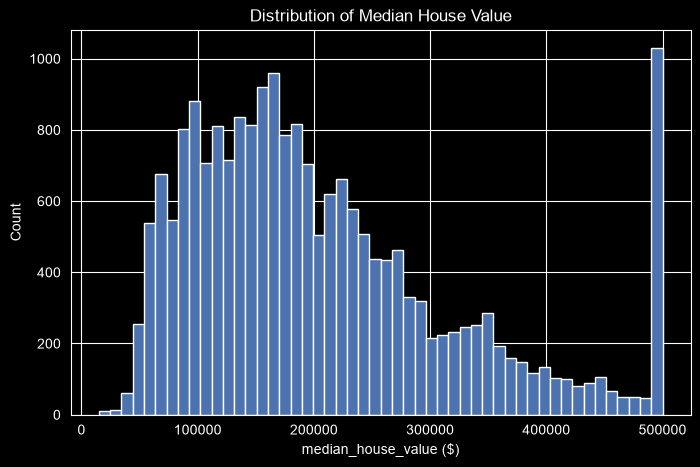

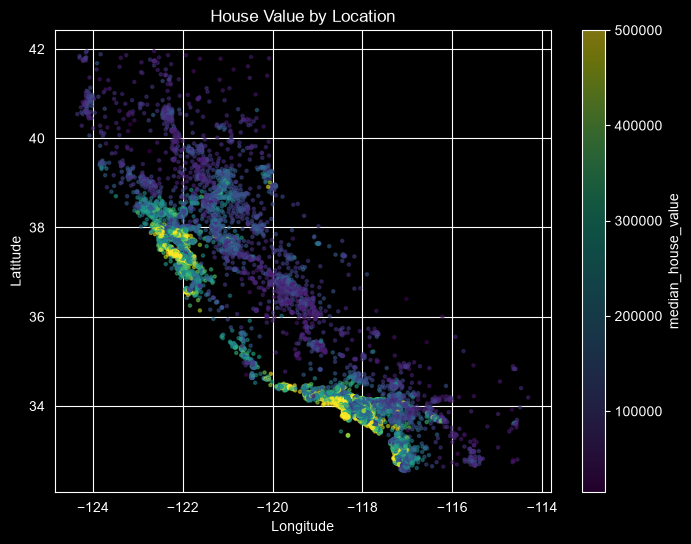

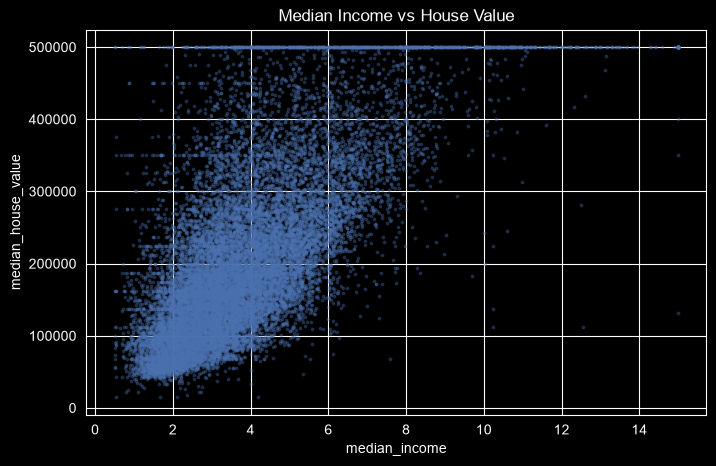

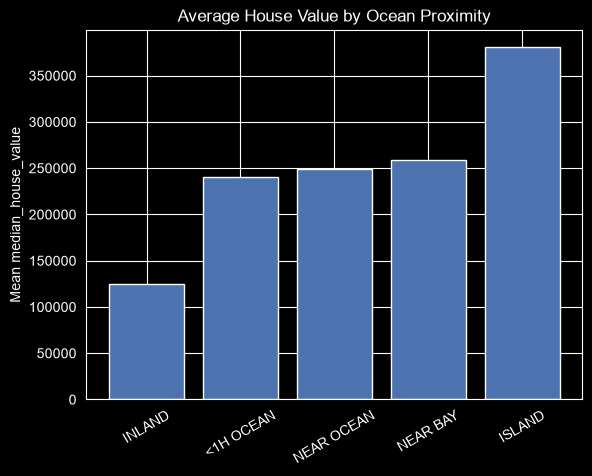

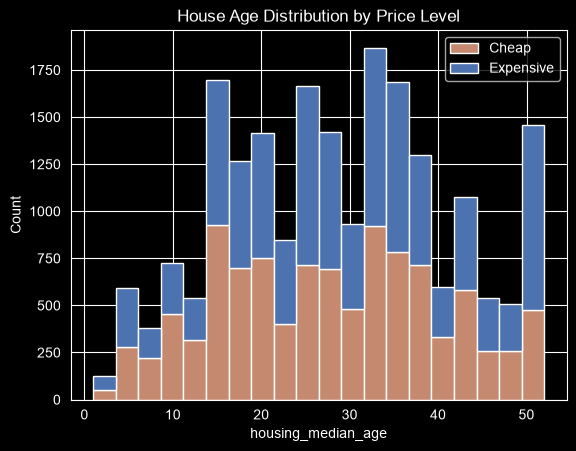

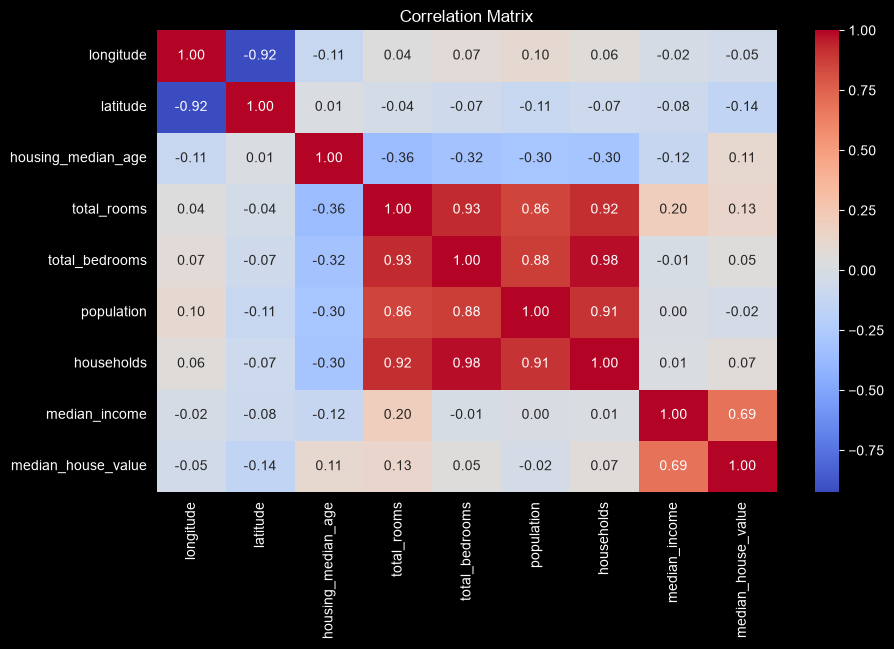

In [70]:
#----------------------- EDA -----------------------
plt.figure(figsize=(8, 5))
plt.hist(data['median_house_value'], bins=50, color='#4c72b0')
plt.title('Distribution of Median House Value')
plt.xlabel('median_house_value ($)')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(data['longitude'], data['latitude'], c=data['median_house_value'], cmap='viridis', s=5, alpha=0.5)
plt.colorbar(label='median_house_value')
plt.title('House Value by Location')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(data['median_income'], data['median_house_value'], s=3, alpha=0.3, color='#4c72b0')
plt.title('Median Income vs House Value')
plt.xlabel('median_income')
plt.ylabel('median_house_value')
plt.show()

rate = data.groupby('ocean_proximity')['median_house_value'].mean().sort_values()
plt.bar(rate.index, rate.values, color='#4c72b0')
plt.title('Average House Value by Ocean Proximity')
plt.ylabel('Mean median_house_value')
plt.xticks(rotation=30)
plt.show()

low = data[data['median_house_value'] < data['median_house_value'].median()]['housing_median_age']
high = data[data['median_house_value'] >= data['median_house_value'].median()]['housing_median_age']
plt.hist([low, high], bins=20, stacked=True, color=["#c4896e", '#4c72b0'], label=['Cheap', 'Expensive'])
plt.title('House Age Distribution by Price Level')
plt.xlabel('housing_median_age')
plt.ylabel('Count')
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
sns.heatmap(data.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [71]:
#------------------------ Линейная регрессия ------------------------
data['total_bedrooms'] = data['total_bedrooms'].fillna(data['total_bedrooms'].median())

y = data['median_house_value']
X = pd.get_dummies(data.drop(columns=['median_house_value']), columns=['ocean_proximity'], drop_first=True, dtype=int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr = LinearRegression()
lr.fit(X_train, y_train)

pred = lr.predict(X_test)

print("mae  =", mean_absolute_error(y_test, pred))
print("rmse =", np.sqrt(mean_squared_error(y_test, pred)))
print("r2   =", r2_score(y_test, pred))

mae  = 50670.7382409721
rmse = 70060.52184473525
r2   = 0.6254240620553599
